In [ ]:
# Execute first
import os
FIG_ROOT = os.environ.get('SCDIS_FIG', os.path.join(os.environ['SCDIS_ROOT'], 'figures'))

# Imports

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os

import local_tools as lt

In [2]:
import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Liberation Sans'
matplotlib.rcParams['mathtext.default'] = 'regular'
matplotlib.rcParams['axes.unicode_minus'] = False

# Original data

In [3]:
save_path = f'{FIG_ROOT}/Prostate/co_clustering'
os.makedirs(save_path, exist_ok=True)

In [4]:
adata_template = sc.read_h5ad(
    f'{os.environ["SCDIS_ROOT"]}/Datasets/preprocessed_datasets/prostate.h5ad'
)

# Renaming and colors

In [5]:
mapping = {
        'T00': 'T0',
        'T01_Cast_Day1': 'C1',
        'T02_Cast_Day7': 'C7',
        'T03_Cast_Day14': 'C14',
        'T04_Cast_Day28': 'C28',
        'T05_Regen_Day1': 'R1',
        'T06_Regen_Day2': 'R2',
        'T07_Regen_Day3': 'R3',
        'T08_Regen_Day7': 'R7',
        'T09_Regen_Day14': 'R14',
        'T10_Regen_Day28': 'R28'
    }

palette = {
    'T0': '#1f77b4',
    'C1': '#ff7f0e',
    'C7': '#279e68',
    'C14': '#d62728',
    'C28': '#aa40fc',
    'R1': '#8c564b',
    'R2': '#e377c2',
    'R3': '#b5bd61',
    'R7': '#17becf',
    'R14': '#aec7e8',
    'R28': '#ffbb78'
    }

time_points = list(mapping.keys())
time_points

['T00',
 'T01_Cast_Day1',
 'T02_Cast_Day7',
 'T03_Cast_Day14',
 'T04_Cast_Day28',
 'T05_Regen_Day1',
 'T06_Regen_Day2',
 'T07_Regen_Day3',
 'T08_Regen_Day7',
 'T09_Regen_Day14',
 'T10_Regen_Day28']

# Compute MAE between L1 & L2

In [6]:
def compute_maes(time_points, n_pcs=2):

    outs = {
        'mae_gt': {}, 
        'mae_pred': {}, 
        'psca_pred':[], 
        'adata_pred':[], 
        'adata_gt':[]
    }

    for tp in tqdm(time_points):
        pred = sc.read_h5ad(f'predictions/{tp}.h5ad')
        gt = sc.read_h5ad(f'ground_truth/{tp}.h5ad')

        pred.obs_names_make_unique()
        gt.obs_names_make_unique()

        pred.var_names = adata_template.var_names.copy()
        gt.var_names = adata_template.var_names.copy()

        pred_stim = pred[pred.obs['time_pred'] == tp].copy()
        gt_stim = gt[gt.obs['time'] == tp].copy()

        outs['psca_pred'].append(
            pred_stim[pred_stim.obs['predType'] == 'Epi_Luminal_2Psca'][:, 'Psca'].X.squeeze()
        )

        outs['adata_pred'].append(
            pred_stim[pred_stim.obs['predType'] == 'Epi_Luminal_2Psca']
        )
        outs['adata_gt'].append(
            gt_stim[gt_stim.obs['predType'] == 'Epi_Luminal_2Psca']
        )

        X_gt = gt_stim.X 
        X_pred = pred_stim.X
      
        pca = PCA(n_components=n_pcs)
        Z_gt = pca.fit_transform(X_gt)
        Z_pred = pca.transform(X_pred)

        gt_l1_mask = gt_stim.obs['predType'] == 'Epi_Luminal_1'
        gt_l2_mask = gt_stim.obs['predType'] == 'Epi_Luminal_2Psca'
        
        pred_l1_mask = pred_stim.obs['predType'] == 'Epi_Luminal_1'
        pred_l2_mask = pred_stim.obs['predType'] == 'Epi_Luminal_2Psca'

        gt_c_l1 = Z_gt[gt_l1_mask].mean(axis=0)
        gt_c_l2 = Z_gt[gt_l2_mask].mean(axis=0)

        pred_c_l1 = Z_pred[pred_l1_mask].mean(axis=0)
        pred_c_l2 = Z_pred[pred_l2_mask].mean(axis=0)
    
        mae_gt = np.abs(gt_c_l1 - gt_c_l2).mean()
        mae_pred = np.abs(pred_c_l1 - pred_c_l2).mean()
        
        outs['mae_gt'][mapping[tp]] = mae_gt
        outs['mae_pred'][mapping[tp]] = mae_pred

    return outs

In [7]:
outs = compute_maes(time_points, n_pcs=2)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:10<00:00,  1.03it/s]


# Psca Expression over C/R cycle

In [8]:
adata_cat_pred = ad.concat(outs['adata_pred'])
adata_cat_pred = lt.rename_time_points(
    adata_cat_pred, 
    obs_name='time_pred',
    obs_name_renamed='time'
    )

adata_cat_gt = ad.concat(outs['adata_gt'])
adata_cat_gt = lt.rename_time_points(
    adata_cat_gt, 
    obs_name='time',
    obs_name_renamed='time'
)

/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [9]:
adata_cat_pred.obs['predType']

T00_Epi_2_id-GCTCCTAAGCGGATCA         Epi_Luminal_2Psca
T00_Epi_2_id-GCTGCTTCAGTATCTG         Epi_Luminal_2Psca
T00_Unsorted_1_id-AGCTCTCCAACTGGCC    Epi_Luminal_2Psca
T00_Unsorted_1_id-CAACTAGTCTGAGTGT    Epi_Luminal_2Psca
T00_Unsorted_1_id-CAGCCGATCAACACCA    Epi_Luminal_2Psca
                                            ...        
T00_intact_2_id-GTCACGGAGACCCACC      Epi_Luminal_2Psca
T00_intact_2_id-TAGACCATCGTACCGG      Epi_Luminal_2Psca
T00_intact_2_id-TGCCCTAAGATATGCA      Epi_Luminal_2Psca
T00_intact_2_id-TGGGAAGAGGTTACCT      Epi_Luminal_2Psca
T00_intact_2_id-TTTATGCGTGATGATA      Epi_Luminal_2Psca
Name: predType, Length: 1067, dtype: category
Categories (1, object): ['Epi_Luminal_2Psca']

In [10]:
# Violon plot

/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:967: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:967: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:967: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:967: FutureWarning: 

Pass

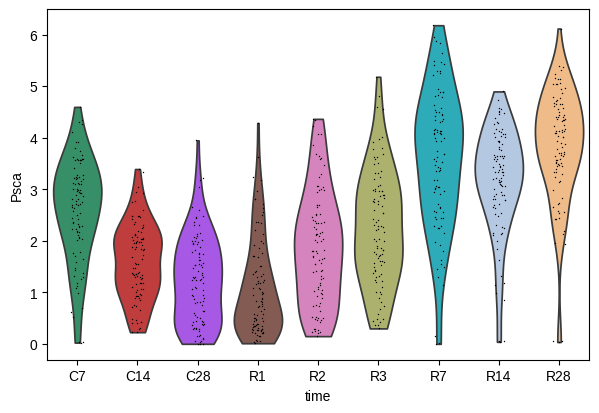

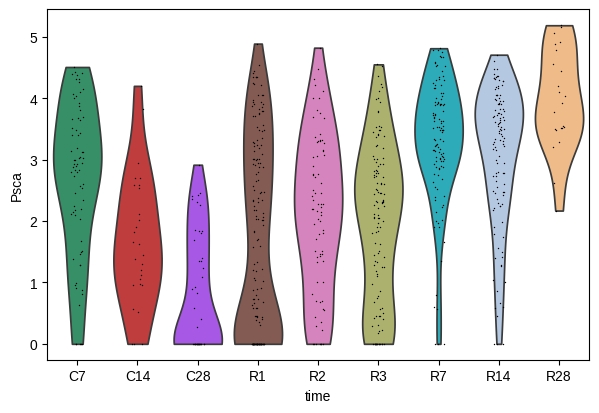

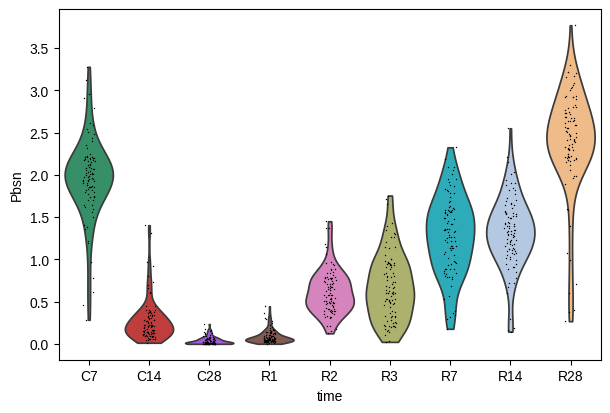

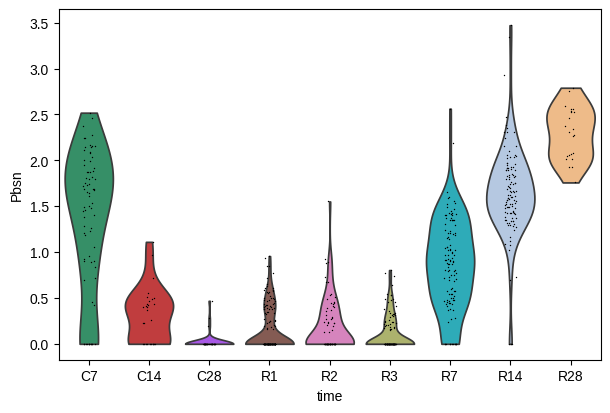

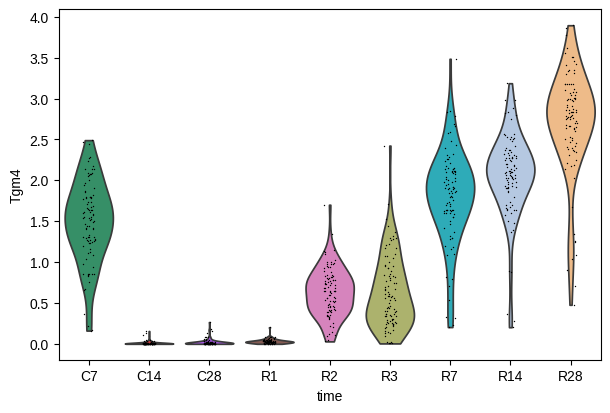

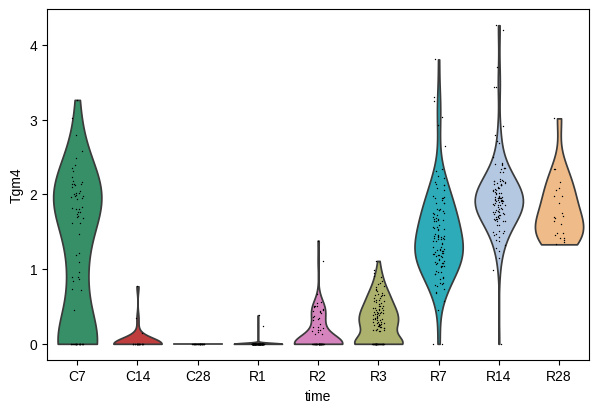

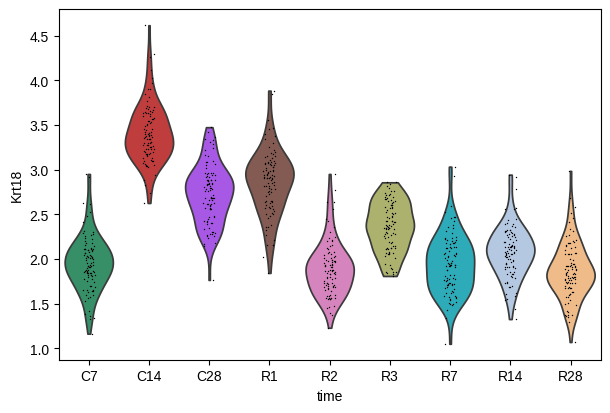

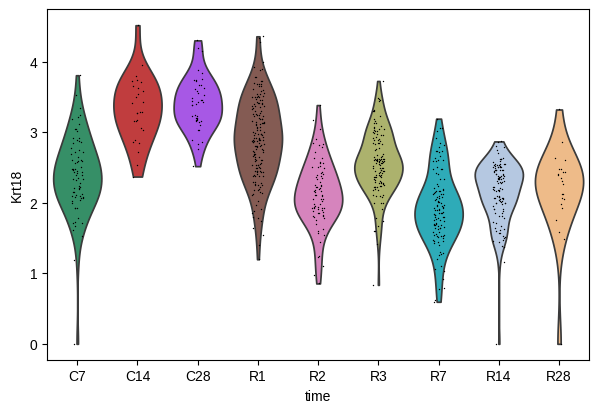

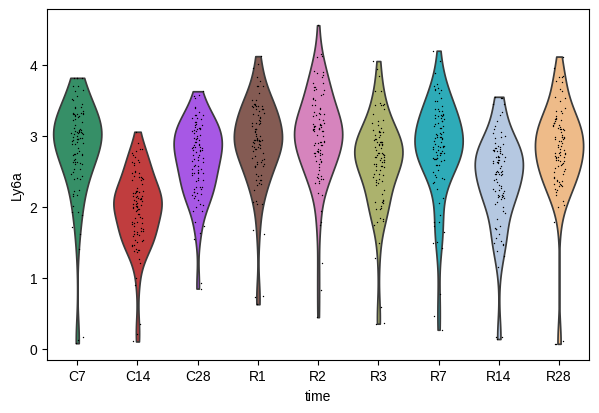

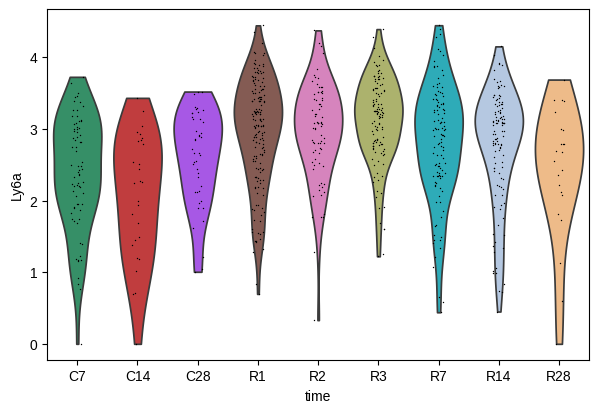

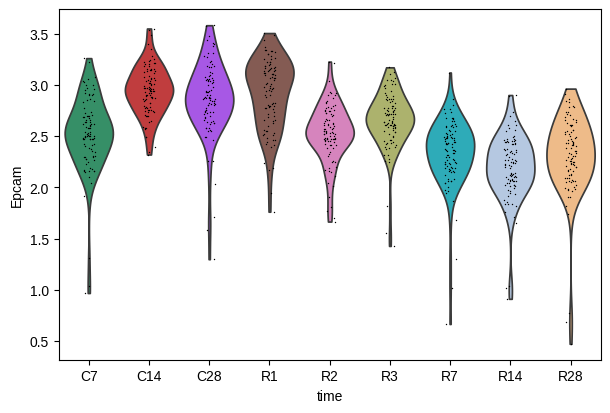

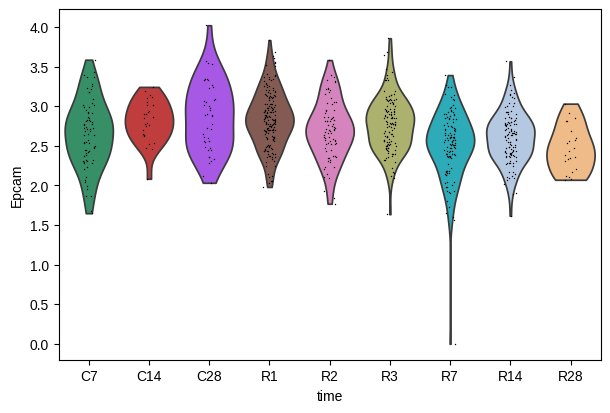

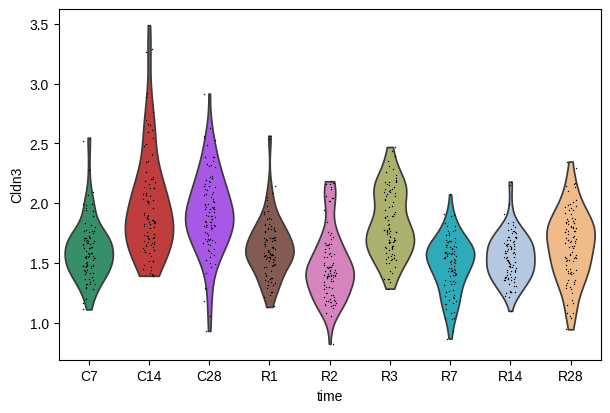

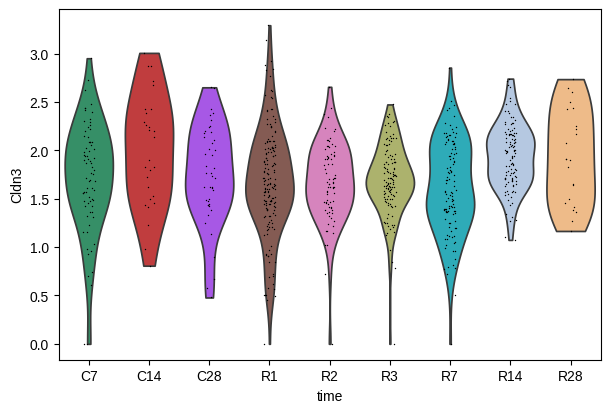

In [11]:
for gene_name in ['Psca', 'Pbsn', 'Tgm4', 'Krt18', 'Ly6a', 'Epcam', 'Cldn3']:
    sc.pl.violin(
        adata_cat_pred[~adata_cat_pred.obs['time'].isin(['T0', 'C1'])],
        keys=gene_name,
        groupby="time",
        stripplot=True,
        jitter=True,
        multi_panel=False,
        show=False,
        palette=palette
    )

    plt.savefig(f'{save_path}/violin_pred_{gene_name}.png', dpi=600)
    plt.savefig(f'{save_path}/violin_pred_{gene_name}.svg', dpi=600)

    sc.pl.violin(
        adata_cat_gt[~adata_cat_gt.obs['time'].isin(['T0', 'C1'])],
        keys=gene_name,
        groupby="time",
        stripplot=True,
        jitter=True,
        multi_panel=False,
        show=False,
        palette=palette
    )

    plt.savefig(f'{save_path}/violin_gt_{gene_name}.png', dpi=600)
    plt.savefig(f'{save_path}/violin_gt_{gene_name}.svg', dpi=600)

In [12]:
# Boxplot

In [13]:
new_palette = {k:v for k,v in palette.items() if not k == 'C1'}
new_palette

{'T0': '#1f77b4',
 'C7': '#279e68',
 'C14': '#d62728',
 'C28': '#aa40fc',
 'R1': '#8c564b',
 'R2': '#e377c2',
 'R3': '#b5bd61',
 'R7': '#17becf',
 'R14': '#aec7e8',
 'R28': '#ffbb78'}

In [14]:
psca_preds = [outs['psca_pred'][0]] + outs['psca_pred'][2:]
len(psca_preds)

10

In [15]:
new_palette

{'T0': '#1f77b4',
 'C7': '#279e68',
 'C14': '#d62728',
 'C28': '#aa40fc',
 'R1': '#8c564b',
 'R2': '#e377c2',
 'R3': '#b5bd61',
 'R7': '#17becf',
 'R14': '#aec7e8',
 'R28': '#ffbb78'}

<module 'matplotlib.pyplot' from '/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/matplotlib/pyplot.py'>

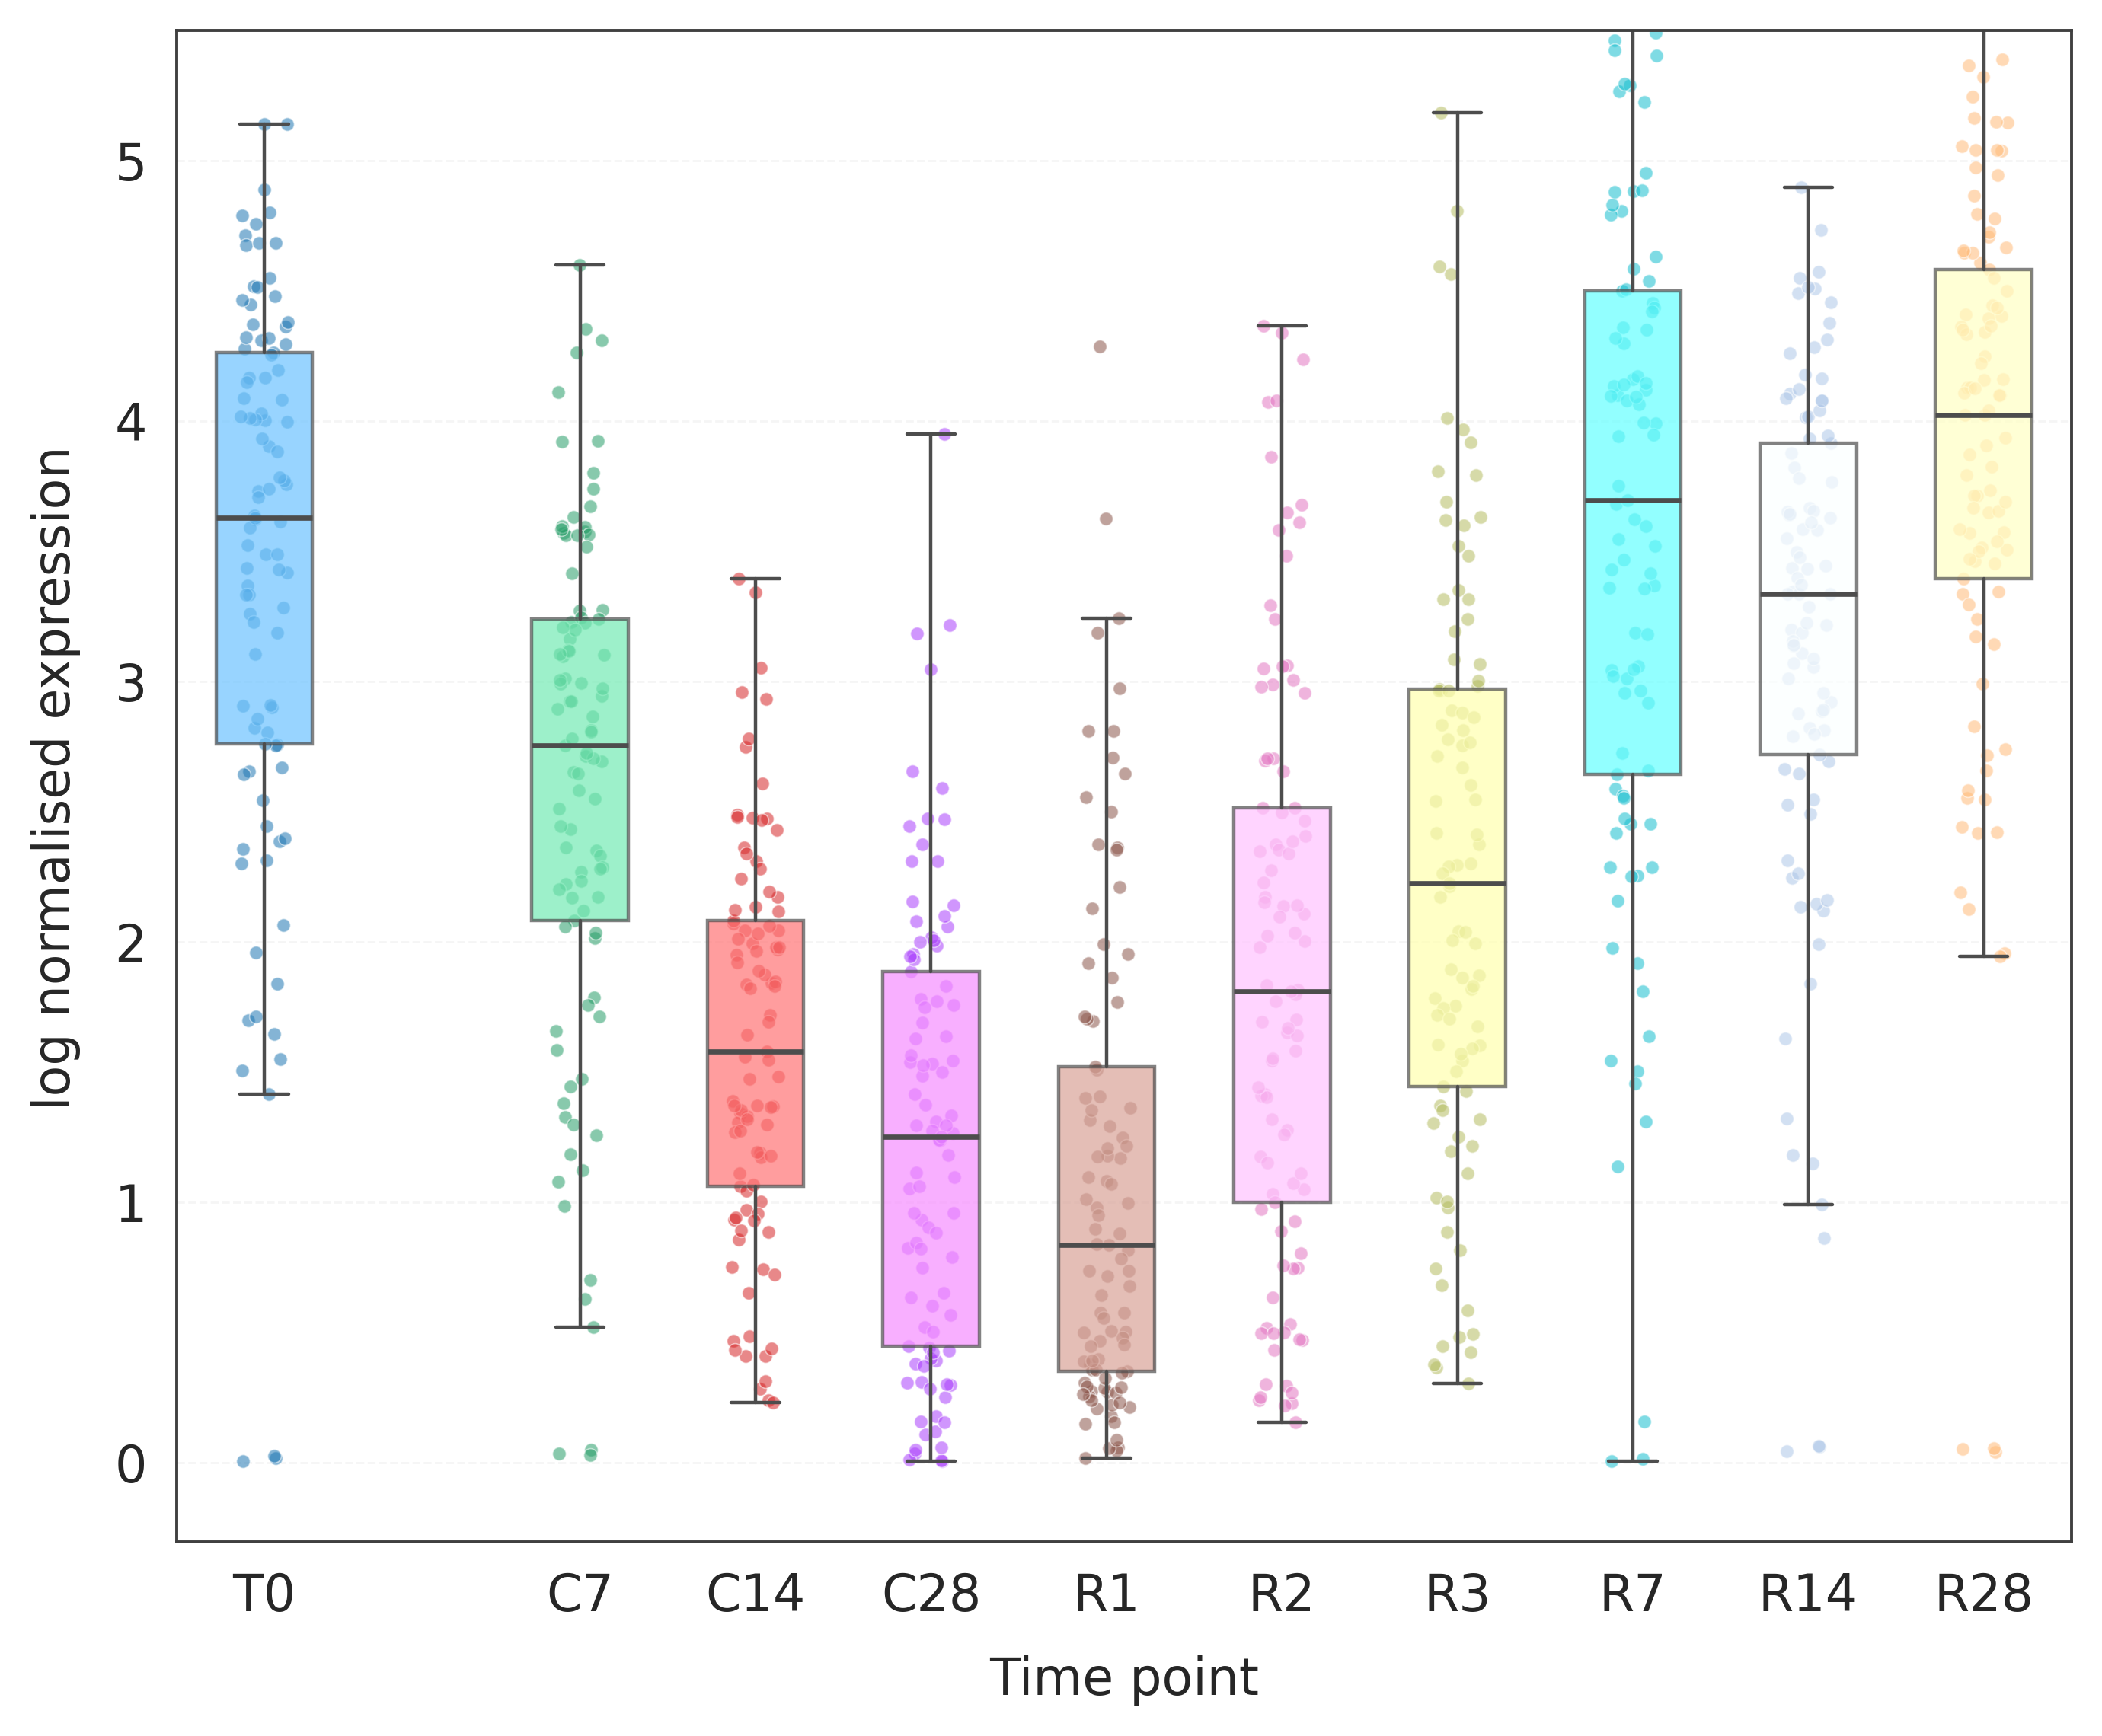

In [16]:
lt.plot_gene_expression_box(
    list(new_palette.keys()), 
    psca_preds, 
    gene_name="", 
    save_path=f'{save_path}/boxplots',
    color_mapping=new_palette, 
    y_max=5.5
)

# Line plots of MAEs between L1 and L2 cell over C/R cycle

In [17]:
# Both Observed and Predicted combined in a single plot

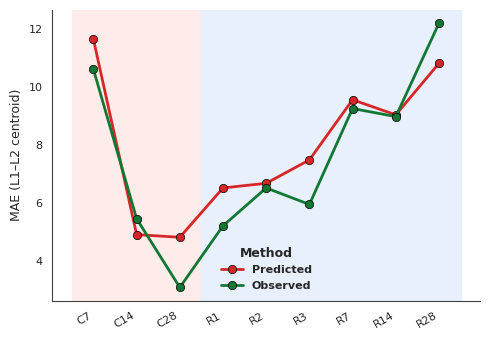

In [18]:
_time_points = list(palette.keys())[2:]


gt_vals = [outs['mae_gt'][t] for t in _time_points]
pred_vals = [outs['mae_pred'][t] for t in _time_points]

fig, ax = plt.subplots(figsize=(5, 3.5))

x = np.arange(len(_time_points))
n_cast = sum(1 for t in _time_points if t.startswith('C'))
lt.phase_bg(ax, n_cast, len(x))

lt.nature_line(ax, x, pred_vals, '#D62728', label='Predicted')
lt.nature_line(ax, x, gt_vals, '#117733', label='Observed')

ax.set_xticks(x)
ax.set_xticklabels(_time_points, fontsize=8, rotation=30, ha='right')
ax.set_ylabel('MAE (L1–L2 centroid)', fontsize=9)
lt.nature_legend(ax, title='Method')
plt.tight_layout()
plt.savefig(f'{save_path}/lineplot_combined.png', dpi=600)
plt.savefig(f'{save_path}/lineplot_combined.svg', dpi=600)

In [19]:
# Predicted and Observed in separate plots

# pvalues of previous time stamps

In [20]:
list(palette.keys())[2:]

['C7', 'C14', 'C28', 'R1', 'R2', 'R3', 'R7', 'R14', 'R28']

In [21]:
tps = list(palette.keys())

In [22]:
tps

['T0', 'C1', 'C7', 'C14', 'C28', 'R1', 'R2', 'R3', 'R7', 'R14', 'R28']

In [23]:
from scipy.stats import ttest_ind, ttest_rel

In [24]:
for gene_name in ['Psca', 'Pbsn', 'Tgm4', 'Krt18', 'Ly6a', 'Epcam', 'Cldn3']:
    for idx, tp in enumerate(tps):
        cur_time = tps[idx]
        
        if idx != 0:
            prev_time = tps[idx-1]
            pval_gt = ttest_ind(
                adata_cat_gt[adata_cat_gt.obs['time'] == cur_time][:, gene_name].X, 
                             
                adata_cat_gt[adata_cat_gt.obs['time'] == prev_time][:, gene_name].X
            )[1]

            pval_pred = ttest_rel(
                adata_cat_pred[adata_cat_pred.obs['time'] == cur_time][:, gene_name].X, 
                             
                adata_cat_pred[adata_cat_pred.obs['time'] == prev_time][:, gene_name].X
            )[1]
            
            print('observed', gene_name, cur_time, prev_time, pval_gt, '\n')
            print('predicted', gene_name, cur_time, prev_time, pval_pred, 'n')

    print('---------------------------\n\n')

observed Psca C1 T0 [0.03637063] 

predicted Psca C1 T0 [1.74857584e-18] n
observed Psca C7 C1 [0.03731681] 

predicted Psca C7 C1 [6.12277998e-05] n
observed Psca C14 C7 [0.00028851] 

predicted Psca C14 C7 [9.51820566e-23] n
observed Psca C28 C14 [0.00095723] 

predicted Psca C28 C14 [3.61177098e-05] n
observed Psca R1 C28 [0.00056399] 

predicted Psca R1 C28 [0.07792354] n
observed Psca R2 R1 [0.02926193] 

predicted Psca R2 R1 [3.61788914e-09] n
observed Psca R3 R2 [0.40688241] 

predicted Psca R3 R2 [0.00030647] n
observed Psca R7 R3 [1.31234516e-15] 

predicted Psca R7 R3 [4.13859222e-24] n
observed Psca R14 R7 [0.12950327] 

predicted Psca R14 R7 [1.68554442e-07] n
observed Psca R28 R14 [0.00042879] 

predicted Psca R28 R14 [3.56103256e-14] n
---------------------------


observed Pbsn C1 T0 [0.54346374] 

predicted Pbsn C1 T0 [0.00309748] n
observed Pbsn C7 C1 [0.70387153] 

predicted Pbsn C7 C1 [2.92165355e-06] n
observed Pbsn C14 C7 [2.15403158e-10] 

predicted Pbsn C14 C7 [5

# Gene mean lineplots

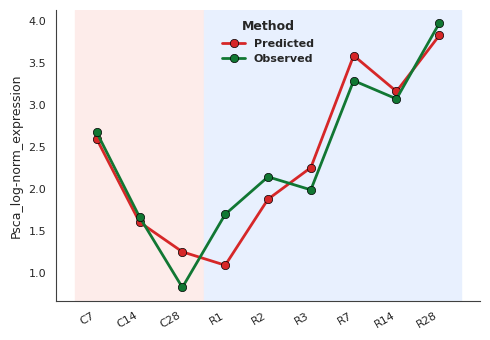

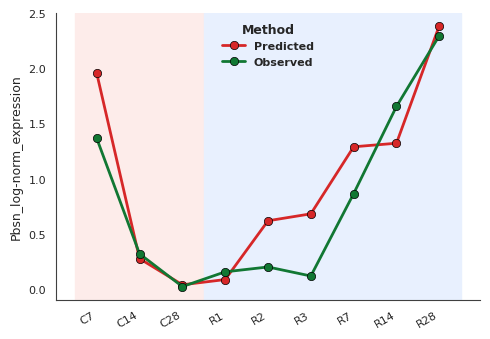

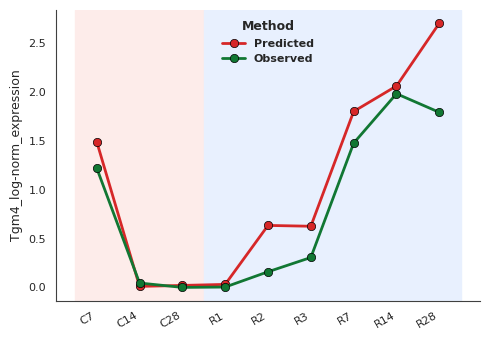

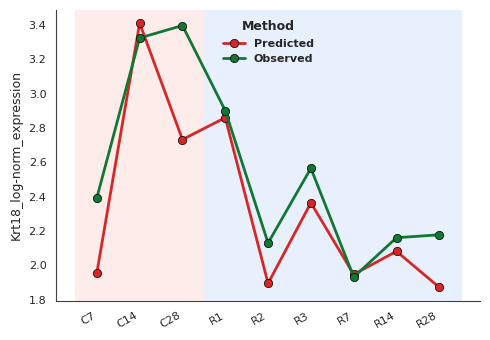

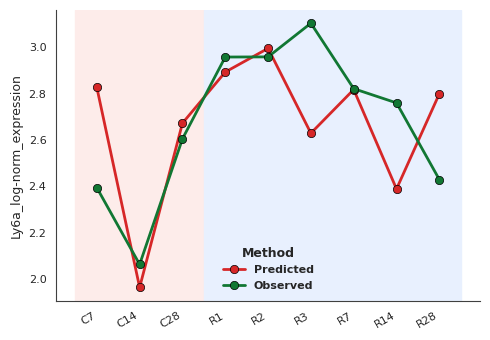

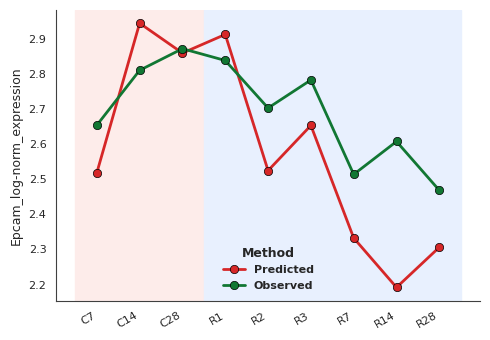

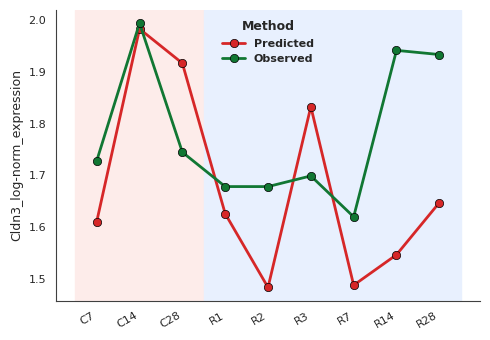

In [25]:
for gene_name in ['Psca', 'Pbsn', 'Tgm4', 'Krt18', 'Ly6a', 'Epcam', 'Cldn3']:
    _time_points = list(palette.keys())[2:]
    
    
    gt_vals = [adata_cat_gt[adata_cat_gt.obs['time'] == t][:, gene_name].X.mean().squeeze() for t in _time_points]
    pred_vals = [adata_cat_pred[adata_cat_pred.obs['time'] == t][:, gene_name].X.mean().squeeze() for t in _time_points]
    
    fig, ax = plt.subplots(figsize=(5, 3.5))
    
    x = np.arange(len(_time_points))
    n_cast = sum(1 for t in _time_points if t.startswith('C'))
    lt.phase_bg(ax, n_cast, len(x))
    
    lt.nature_line(ax, x, pred_vals, '#D62728', label='Predicted')
    lt.nature_line(ax, x, gt_vals, '#117733', label='Observed')
    
    ax.set_xticks(x)
    ax.set_xticklabels(_time_points, fontsize=8, rotation=30, ha='right')
    ax.set_ylabel(f'{gene_name}_log-norm_expression', fontsize=9)
    lt.nature_legend(ax, title='Method')
    plt.tight_layout()
    plt.savefig(f'{save_path}/{gene_name}_line_progression.png', dpi=600)
    plt.savefig(f'{save_path}/{gene_name}_line_progression.svg', dpi=600)